Training on device: cuda
Loading MNIST data... (This might take a few seconds)

Starting Training with PyTorch BatchNorm1d...

Epoch      | Train Loss   | Train Acc    | Test Loss    | Test Acc    
-----------------------------------------------------------------
Epoch 1    | 0.2316       | 94.07     % | 0.0984       | 96.92     %
Epoch 2    | 0.0914       | 97.14     % | 0.0760       | 97.57     %
Epoch 3    | 0.0653       | 97.94     % | 0.0700       | 97.73     %
Epoch 4    | 0.0500       | 98.42     % | 0.0708       | 97.90     %
Epoch 5    | 0.0407       | 98.70     % | 0.0612       | 98.15     %
Epoch 6    | 0.0333       | 98.93     % | 0.0602       | 98.18     %
Epoch 7    | 0.0309       | 99.00     % | 0.0707       | 97.87     %
Epoch 8    | 0.0267       | 99.08     % | 0.0656       | 98.19     %
Epoch 9    | 0.0234       | 99.26     % | 0.0610       | 98.28     %
Epoch 10   | 0.0205       | 99.32     % | 0.0689       | 98.06     %

Training complete!


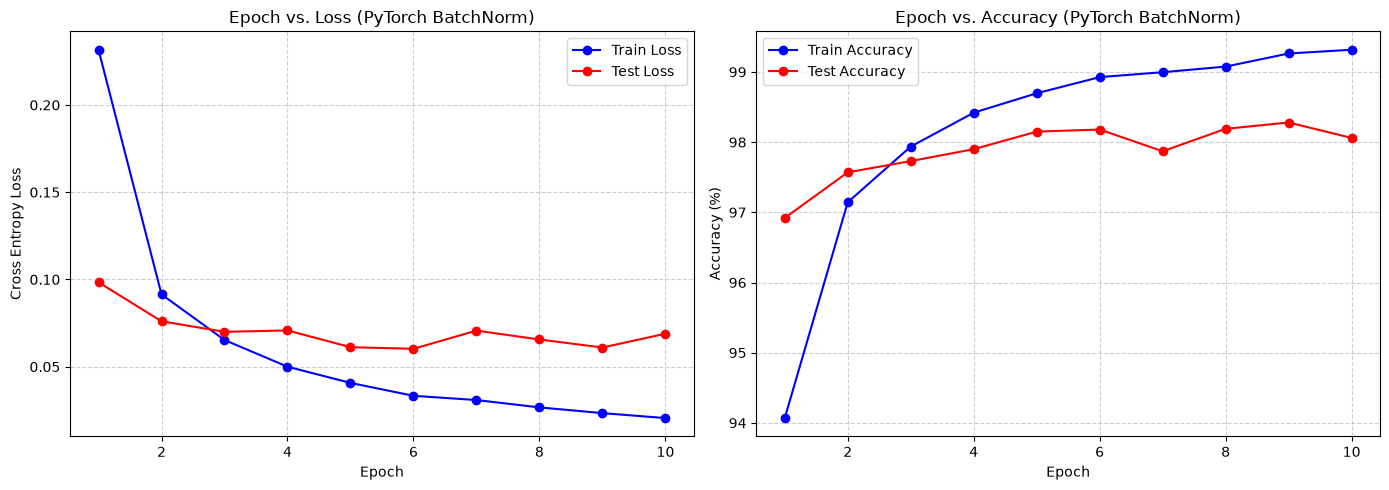

In [1]:
#task 3

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on device: {device}")
print("Loading MNIST data... (This might take a few seconds)")

train_df = pd.read_csv('mnist_train.csv')
test_df = pd.read_csv('mnist_test.csv')


X_train = train_df.iloc[:, 1:].values / 255.0
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values / 255.0
y_test = test_df.iloc[:, 0].values


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long) 
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)


model_bn_native = nn.Sequential(
    nn.Linear(784, 256),
    nn.BatchNorm1d(256), 
    nn.ReLU(),
    
    nn.Linear(256, 128),
    nn.BatchNorm1d(128), 
    nn.ReLU(),
    
    nn.Linear(128, 64),
    nn.BatchNorm1d(64), 
    nn.ReLU(),
    
    nn.Linear(64, 10) 
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_bn_native.parameters(), lr=0.001)


epochs = 10
print("\nStarting Training with PyTorch BatchNorm1d...\n")
print(f"{'Epoch':<10} | {'Train Loss':<12} | {'Train Acc':<12} | {'Test Loss':<12} | {'Test Acc':<12}")
print("-" * 65)

train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

for epoch in range(epochs):
  
    model_bn_native.train() 
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model_bn_native(X_batch)
        
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()
        
    avg_train_loss = running_train_loss / total_train
    train_acc = (correct_train / total_train) * 100

    model_bn_native.eval() 
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0
    
    with torch.no_grad(): 
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model_bn_native(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_test_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            total_test += y_batch.size(0)
            correct_test += (predicted == y_batch).sum().item()
            
    avg_test_loss = running_test_loss / total_test
    test_acc = (correct_test / total_test) * 100
    
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(avg_test_loss)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1:<4} | {avg_train_loss:<12.4f} | {train_acc:<10.2f}% | {avg_test_loss:<12.4f} | {test_acc:<10.2f}%")

print("\nTraining complete!")

plt.figure(figsize=(14, 5))
epochs_range = range(1, epochs + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(epochs_range, test_losses, label='Test Loss', color='red', marker='o')
plt.title('Epoch vs. Loss (PyTorch BatchNorm)')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy', color='blue', marker='o')
plt.plot(epochs_range, test_accuracies, label='Test Accuracy', color='red', marker='o')
plt.title('Epoch vs. Accuracy (PyTorch BatchNorm)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()